In [1]:
!pip install scikit-image scikit-learn matplotlib

In [2]:
!git clone https://github.com/MohammadaminKafi/techstack2025-ai.git

Cloning into 'techstack2025-ai'...
remote: Enumerating objects: 1143, done.
remote: Counting objects: 100% (644/644), done.
remote: Compressing objects: 100% (640/640), done.
remote: Total 1143 (delta 5), reused 633 (delta 2), pack-reused 499 (from 2)
Receiving objects: 100% (1143/1143), 92.59 MiB | 22.91 MiB/s, done.
Resolving deltas: 100% (34/34), done.


Total number of images loaded: 615
Images shape: (615, 128, 128)
Labels shape: (615,)
Number of cats: 260
Number of dogs: 355
Full HOG features shape: (1230, 1764)
Training data shape: (984, 1764), Test data shape: (246, 1764)
Number of training labels: 984, Number of test labels: 246
Random Forest classifier trained successfully.
Test Accuracy: 0.9228
Visualization saved to classification_results.png


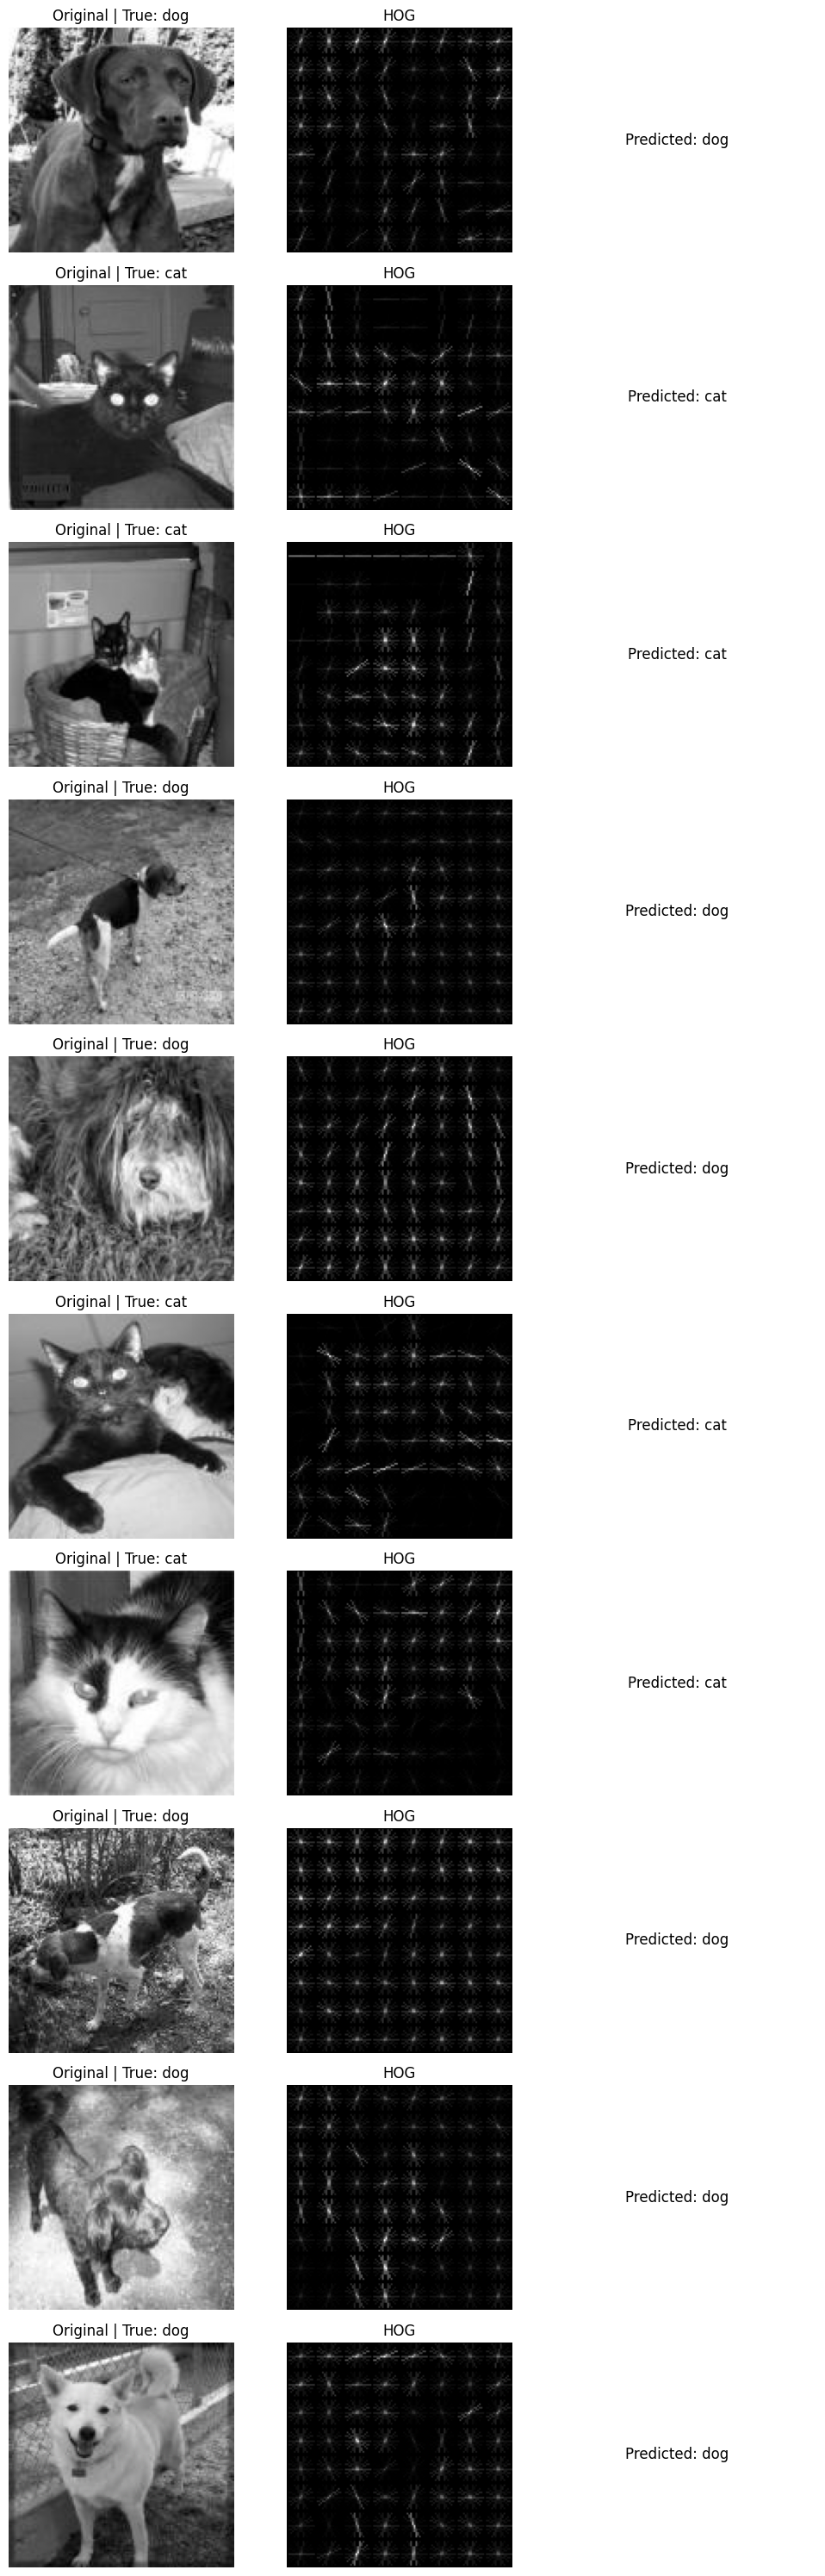

In [9]:
import os
import numpy as np
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.feature import hog
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data_dir = './techstack2025-ai/week4/task/dataset'
img_data, lbls = [], []

if not os.path.exists(data_dir):
    print(f"Error: The directory '{data_dir}' does not exist. Please ensure the GitHub repository has been cloned correctly.")
else:
    for file in os.listdir(data_dir):
        if file.endswith('.jpg'):
            img_path = os.path.join(data_dir, file)
            if file.startswith('cat'):
                lbls.append(0)
            elif file.startswith('dog'):
                lbls.append(1)
            else:
                continue

            try:
                img = imread(img_path)
                img = rgb2gray(img)
                img_resized = resize(img, (128, 128), anti_aliasing=True)
                img_data.append(img_resized)
            except Exception as e:
                print(f"Could not read image {file}: {e}")

img_data = np.array(img_data)
lbls = np.array(lbls)
print(f"Total number of images loaded: {len(img_data)}")
print('Images shape:', img_data.shape)
print('Labels shape:', lbls.shape)
print(f'Number of cats: {np.sum(lbls == 0)}')
print(f'Number of dogs: {np.sum(lbls == 1)}')

def extract_hog_features(images, visualize=False):
    hog_features = []
    hog_images = []
    for image in images:
        features, hog_image = hog(image, orientations=9, pixels_per_cell=(16, 16),
                                  cells_per_block=(2, 2), visualize=True,
                                  transform_sqrt=True, block_norm='L2-Hys')
        hog_features.append(features)
        if visualize:
            hog_images.append(hog_image)

    hog_features = np.array(hog_features)
    hog_images = np.array(hog_images) if visualize else None

    return hog_features, hog_images

def train_classifier(X_train, y_train):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train, y_train)
    return clf

def evaluate_model(clf, X_test, y_test):
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    return accuracy, y_pred


img_data_flipped = np.array([np.fliplr(img) for img in img_data])
full_img_data = np.concatenate((img_data, img_data_flipped), axis=0)
full_lbls = np.concatenate((lbls, lbls), axis=0)


full_hog_features, full_hog_images = extract_hog_features(full_img_data, visualize=True)

print('Full HOG features shape:', full_hog_features.shape)


X_train, X_test, y_train, y_test, _, idx_test = train_test_split(
    full_hog_features, full_lbls, np.arange(len(full_lbls)),
    test_size=0.2, random_state=42, stratify=full_lbls
)

print(f"Training data shape: {X_train.shape}, Test data shape: {X_test.shape}")
print(f"Number of training labels: {len(y_train)}, Number of test labels: {len(y_test)}")

clf = train_classifier(X_train, y_train)
print("Random Forest classifier trained successfully.")

accuracy, y_pred = evaluate_model(clf, X_test, y_test)
print(f'Test Accuracy: {accuracy:.4f}')

classes = ['cat', 'dog']
sample_indices = np.random.choice(idx_test, 10, replace=False)

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(10, 3 * len(sample_indices)))
if len(sample_indices) == 1:
    axes = np.array([axes])

for i, idx in enumerate(sample_indices):
    original_image = full_img_data[idx]
    hog_vis = full_hog_images[idx]

    true_label = full_lbls[idx]
    pred_label = y_pred[np.where(idx_test == idx)[0][0]]

    axes[i, 0].imshow(original_image, cmap='gray')
    axes[i, 0].set_title(f'Original | True: {classes[true_label]}')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(hog_vis, cmap='gray')
    axes[i, 1].set_title('HOG')
    axes[i, 1].axis('off')

    axes[i, 2].text(0.5, 0.5, f'Predicted: {classes[pred_label]}',
                     horizontalalignment='center', verticalalignment='center',
                     fontsize=12, transform=axes[i, 2].transAxes)
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig('classification_results.png')
print("Visualization saved to classification_results.png")

This project deepened my understanding of the importance of **feature extraction** and choosing the right **classifier** in classical machine learning tasks.

---

### HOG

I learned that instead of working with raw pixel values, it's more effective to extract higher-level features like gradients. By focusing on edge and texture patterns, **HOG** provides a rich description of an image, which makes it very effective for object detection and recognition.

---

### Decision Trees

Although a **Decision Tree** is a simple and interpretable model, I realized it might not handle complex data well on its own. Using a **Random Forest** showed me how combining several simple models can create a much more powerful and stable one. This experience truly highlighted the strength of **ensemble learning** methods.